# Disequazioni irrazionali

Per prima cosa vediamo come fare le radici $n$-esime in Sage. 
Per radicandi positivi possiamo usare le potenze:

In [1]:
8^(1/3)

2

Se vogliamo applicare le radici con indici dispari a radicandi negativi è meglio usare il metodo `.nth_root`. Vediamo un esempio:

In [2]:
a=(-8)^(1/3)   # base negativa
show(a.n())

1.00000000000000 + 1.73205080756888*I

In [3]:
(-8).nth_root(3) 

-2

In [4]:
8.nth_root(3)

2

Il seguente codice crea una funzione per avere funzioni $x^{p/q}$ ben definite anche per $x<0$ quando $q$ è dispari:

In [5]:
x=var('x')
def power_pq(x,p,q):
    if is_odd(q):
        val=((sign(x))^p)*abs(x)^(p/q)
    else:
        val=x^(p/q)   
    return val

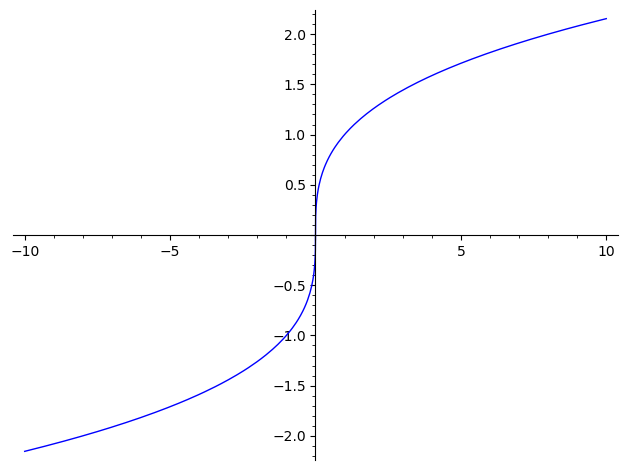

In [6]:
f(x)=power_pq(x,1,3) # esempio di radice cubica
plot(f,[-10,10])

## Risoluzione di disequazioni irrazionali

### Esempio 1

Risolvere $$1\leq x-2\sqrt{2x-3}$$

In [7]:
%display latex
dis=1<=x-2*sqrt(2*x-3)
dis

1 <= x - 2*sqrt(2*x - 3)

A volte è utile aggiungere l'opzione `algorithm='sympy'` al comando `solve`, ma in questo caso comunque non riesce a trovare le soluzioni esatte:

In [8]:
solve(dis,algorithm='sympy')

[[x <= -2*sqrt(3) + 5], [x >= 2*sqrt(3) + 5]]

Vediamo i passaggi per risolvere questa disequazione irrazionale:

In [9]:
dis1=(dis-x)/2
dis1

-1/2*x + 1/2 <= -sqrt(2*x - 3)

Invece di moltiplicare per $-1$, invertiamo i membri:

In [10]:
dis2=dis1-dis1.right()-dis1.left()
dis2

sqrt(2*x - 3) <= 1/2*x - 1/2

In [11]:
f(x)=dis2.left()^2
g(x)=dis2.right()

 $$\text{Caso 1):}\  \begin{cases}
g(x)\geq 0\\
f(x)\geq 0\\
f(x)\leq g^2(x)
\end{cases}\quad ,\quad  \text{Caso 2):}\ \begin{cases}
g(x)< 0\\
f(x)\geq 0\\
\sqrt{f(x)}\leq g(x) 
\end{cases}
\implies \nexists $$

In [12]:
solve(g(x)>=0)

[[x >= 1]]

In [13]:
solve(f(x)>=0)

[[x >= (3/2)]]

In [14]:
dis3=f(x)<=(g(x))^2
dis3=dis3.expand()
dis3=dis3-dis3.right()
dis3()

-1/4*x^2 + 5/2*x - 13/4 <= 0

In [15]:
solve(dis3)

[[x <= -2*sqrt(3) + 5], [x >= 2*sqrt(3) + 5]]

In [16]:
solve([x>=3/2,dis3])

[[(3/2) < x, x^2 - 10*x + 13 == 0],
 [(3/2) < x, x^2 - 10*x + 13 > 0],
 [x == (3/2), (1/4) == 0],
 [x == (3/2), (1/4) > 0]]

### Esempio 2

Risolvere
$$\sqrt{2x-1}-\sqrt{x-4}>2$$

In [18]:
eqn=sqrt(2*x-1)-sqrt(x-4)>2
eqn

sqrt(2*x - 1) - sqrt(x - 4) > 2

In [21]:
solve(eqn,algorithm='sympy')

[[[x >= 4], [x < 5]], [x > 13]]

Vediamo i passaggi.
Per prima cosa le condizioni di esistenza:

In [24]:
CE1=solve(2*x-1>=0)
CE2=solve(x-4>=0)
CE1+CE2

[[x >= (1/2)], [x >= 4]]

In [33]:
eqn1=eqn^2
show(eqn1)
eqn2=eqn1.expand()
show(eqn2)

(sqrt(2*x - 1) - sqrt(x - 4))^2 > 4

-2*sqrt(2*x - 1)*sqrt(x - 4) + 3*x - 5 > 4

In [36]:
eqn3=(eqn2-3*x+5)/2
show(eqn3)
eqn4=eqn3-eqn3.left()-eqn3.right()
show(eqn4)

-sqrt(2*x - 1)*sqrt(x - 4) > -3/2*x + 9/2

3/2*x - 9/2 > sqrt(2*x - 1)*sqrt(x - 4)

In [41]:
g(x)=eqn4.left()
f(x)=(eqn4.right())^2
show(g(x))
show(f(x))

3/2*x - 9/2

(2*x - 1)*(x - 4)

In [42]:
solve(g(x)>=0)

[[x >= 3]]

In [47]:
eqn5=(g(x))^2>f(x)
show(eqn5)
solve(eqn5)

9/4*(x - 3)^2 > (2*x - 1)*(x - 4)

[[x < 5], [x > 13]]

## Grafico di funzioni potenza

Facciamo il grafico di funzioni del tipo
$$y=x^{\alpha}$$
dove $x>0$ e $\alpha\in \mathbb{R}$

Usiamo un slider:

In [49]:
@interact
def _(a=slider(-3,3,step_size=0.1)):
    show(plot(x^a,(x,0, 3),ymin=-1,ymax=10, color='red'))

Interactive function <function _ at 0x16d4a1a80> with 1 widget
  a: TransformFloatSlider(value=0.0, description='a', max=3.0, min=-3.0)

## Esempi visti a lezione 

### Esempio - indice dispari

Riproponiamo l'esempio visto nella lezione:

$$\sqrt[3]{x^3-16}\geq -x$$


In [ ]:
%display latex
dis1=power_pq(x^3-16,1,3)>=-x

In [ ]:
dis1

In [ ]:
solve(dis1,algorithm='sympy')

In [ ]:
dis=((x^3-16)^(1/3)>=-x)

In [ ]:
solve(dis,to_poly_solve=true)

In questo caso `solve` non riesce a trovare la soluzione.
Facciamo i passaggi per la risoluzine:

In [ ]:
dis2=dis^3
dis2

In [ ]:
solve(dis2)

In questo caso è facile fare tutti i passaggi per arrivare alla fine

In [ ]:
dis3=dis2+x^3+16
dis4=dis3/2
show(dis4)


In [ ]:
dis5=dis4^(1/3)
show(dis5)
show(dis5.canonicalize_radical())

### Esempio - indice pari

In [ ]:
dis=sqrt(x^2-9)>= 3-1/5*x
dis

In [ ]:
solve(dis,algorithm='sympy')

Facciamo i passaggi.
Caso 1: rhs >=0
Risolviamo:

$$\text{Caso 1}\  \begin{cases}
-\frac15 x+3\geq 0 \\
x^2-9\geq 0\\
x^2-9\geq (-\frac 15 x+3)^2
\end{cases}\qquad,\qquad \text{Caso 2}\ \begin{cases}
-\frac15 x+3< 0 \\
x^2-9\geq 0\\
\end{cases} $$

In [ ]:
g(x)=dis.right()
g(x)

In [ ]:
f(x)=x^2-9

In [ ]:
dis^2

In [ ]:
S1=solve([g(x)>=0,f(x)>=0,dis^2])
S1

In [ ]:
S2=solve([g(x)<0,f(x)>=0])
S1+S2